In [ ]:
# !pip install tensorflow
# import tensorflow as tf
# print(tf.__version__)
!pip install --upgrade segmentation_models
!pip install pydot graphviz

In [ ]:
import site
# This will print the paths where your Python packages are installed.
# Look for the 'efficientnet' package within these directories.
print(site.getsitepackages())

['/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.11/dist-packages']


# New Section

In [ ]:
import tensorflow as tf
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
from tensorflow import keras
import segmentation_models as sm
import glob
import cv2
# import os
import numpy as np
from matplotlib import pyplot as plt
import keras
from google.colab import drive
from keras.utils import normalize
from keras.metrics import MeanIoU
from tensorflow.keras.utils import plot_model
from google.colab import files

from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

import os
for root, dirs, files in os.walk("/content/drive/MyDrive/Dataset"):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files)



# Function to get sorted file paths
def get_sorted_file_paths(directory, extension="*.png", limit=500):
    file_paths = sorted(glob.glob(os.path.join(directory, extension)))[:limit]
    print("pTH IS ",file_paths)
    return file_paths

# Load and resize images (only first 500 in sorted order)
SIZE_X = 128
SIZE_Y = 128
n_classes = 4

# Load images
train_images = []
image_paths = get_sorted_file_paths("/content/drive/MyDrive/Dataset/images/")
for img_path in image_paths:
    img = cv2.imread(img_path, 1)
    img = cv2.resize(img, (SIZE_Y, SIZE_X))
    train_images.append(img)

train_images = np.array(train_images)

# Load masks
train_masks = []
mask_paths = get_sorted_file_paths("/content/drive/MyDrive/Dataset/masks/")
for mask_path in mask_paths:
    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (SIZE_Y, SIZE_X), interpolation=cv2.INTER_NEAREST)
    train_masks.append(mask)

train_masks = np.array(train_masks)
print("Image paths:", image_paths)
print("Mask paths:", mask_paths)

print(f"Loaded {len(train_images)} images and {len(train_masks)} masks.")


###############################################
#Encode labels... but multi dim array so need to flatten, encode and reshape
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
n, h, w = train_masks.shape
train_masks_reshaped = train_masks.reshape(-1,1)
train_masks_reshaped_encoded = labelencoder.fit_transform(train_masks_reshaped)
train_masks_encoded_original_shape = train_masks_reshaped_encoded.reshape(n, h, w)

np.unique(train_masks_encoded_original_shape)

#################################################
#train_images = np.expand_dims(train_images, axis=3)
#train_images = normalize(train_images, axis=1)

train_masks_input = np.expand_dims(train_masks_encoded_original_shape, axis=3)

#Create a subset of data for quick testing
#Picking 10% for testing and remaining for training
from sklearn.model_selection import train_test_split
X1, X_test, y1, y_test = train_test_split(train_images, train_masks_input, test_size = 0.10, random_state = 0)

#Further split training data t a smaller subset for quick testing of models
X_train, X_do_not_use, y_train, y_do_not_use = train_test_split(X1, y1, test_size = 0.5, random_state = 0)

print("Class values in the dataset are ... ", np.unique(y_train))  # 0 is the background/few unlabeled

from keras.utils import to_categorical
train_masks_cat = to_categorical(y_train, num_classes=n_classes)
y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], n_classes))



test_masks_cat = to_categorical(y_test, num_classes=n_classes)
y_test_cat = test_masks_cat.reshape((y_test.shape[0], y_test.shape[1], y_test.shape[2], n_classes))

######################################################
#Reused parameters in all models

n_classes=4
activation='softmax'

LR = 0.0001
optim = keras.optimizers.Adam(LR)

# Segmentation models losses can be combined together by '+' and scaled by integer or float factor
# set class weights for dice_loss (car: 1.; pedestrian: 2.; background: 0.5;)
dice_loss = sm.losses.DiceLoss(class_weights=np.array([0.25, 0.25, 0.25, 0.25]))
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)



# actulally total_loss can be imported directly from library, above example just show you how to manipulate with losses
# total_loss = sm.losses.binary_focal_dice_loss # or sm.losses.categorical_focal_dice_loss

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]


########################################################################
###Model 1
BACKBONE1 = 'resnet34'
preprocess_input1 = sm.get_preprocessing(BACKBONE1)

# preprocess input
X_train1 = preprocess_input1(X_train)
X_test1 = preprocess_input1(X_test)

# define model
model1 = sm.Unet(BACKBONE1, encoder_weights='imagenet', classes=n_classes, activation=activation)

plot_model(model, to_file='unet_resnet34_model.png', show_shapes=True, show_layer_names=True)

# compile keras model with defined optimozer, loss and metrics
model1.compile(optim, total_loss, metrics=metrics)

#model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)

print(model1.summary())


history1=model1.fit(X_train1,
          y_train_cat,
          batch_size=8,
          epochs=50,
          verbose=1,
          validation_data=(X_test1, y_test_cat))


model1.save('res34_backbone_50epochs.hdf5')

Mounted at /content/drive/
Root: /content/drive/MyDrive/Dataset
Directories: ['resized_images', 'resized_masks', 'masks', 'images', 'noisy_images_2pt']
Files: ['UNet_Model_save.hdf5', 'UNet_Model_save_new.hdf5', 'UNet_Model_save_new_latest.hdf5', 'Training_and_validation_loss.png', 'Training_and_validation_jacard.png', 'confusion_matrix.csv', 'classification_report.txt', 'metrics.csv']
Root: /content/drive/MyDrive/Dataset/resized_images
Directories: []
Files: ['1132.png', '1122.png', '1176.png', '1151.png', '1162.png', '1169.png', '1158.png', '1153.png', '1165.png', '1149.png', '1166.png', '1160.png', '1171.png', '1147.png', '1174.png', '1154.png', '1177.png', '1161.png', '1175.png', '1170.png', '1163.png', '1157.png', '117.png', '1159.png', '1179.png', '1152.png', '1155.png', '115.png', '1173.png', '1164.png', '1156.png', '1172.png', '116.png', '1150.png', '1178.png', '1167.png', '1168.png', '1148.png', '1202.png', '1180.png', '1190.png', '1204.png', '121.png', '1206.png', '1207.png',

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Class values in the dataset are ...  [0 1]


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, None,      │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_68   │ (None, None,      │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, None,      │      9,408 │ zero_padding2d_6… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, None,      │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, None,      │          0 │ bn0[0][0]         │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_69   │ (None, None,      │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, None,      │          0 │ zero_padding2d_6… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, None,      │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, None,      │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_70   │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, None,      │     36,864 │ zero_padding2d_7… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, None,      │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, None,      │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_71   │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, None,      │     36,864 │ zero_padding2d_7… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, None,      │      4,096 │ stage1_unit1_rel

 Total params: 24,456,589 (93.29 MB)

 Trainable params: 24,439,239 (93.23 MB)

 Non-trainable params: 17,350 (67.77 KB)

None
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 66s 818ms/step - f1-score: 0.0165 - iou_score: 0.0084 - loss: 1.0336 - val_f1-score: 0.0793 - val_iou_score: 0.0754 - val_loss: 1.1526
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - f1-score: 0.1291 - iou_score: 0.0995 - loss: 0.9944 - val_f1-score: 0.3706 - val_iou_score: 0.3480 - val_loss: 1.0134
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - f1-score: 0.2728 - iou_score: 0.2152 - loss: 0.9743 - val_f1-score: 0.4162 - val_iou_score: 0.3758 - val_loss: 0.9898
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - f1-score: 0.2861 - iou_score: 0.2369 - loss: 0.9645 - val_f1-score: 0.5841 - val_iou_score: 0.5242 - val_loss: 0.9776
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - f1-score: 0.3945 - iou_score: 0.3419 - loss: 0.9574 - val_f1-score: 0.7096 - val_iou_score: 0.6456 - val_loss: 0.9668
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - f1-score: 0.5934 - iou_score: 0.5448 - loss: 0.9519 - val_f1-score: 0.6902 - val_iou_

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━

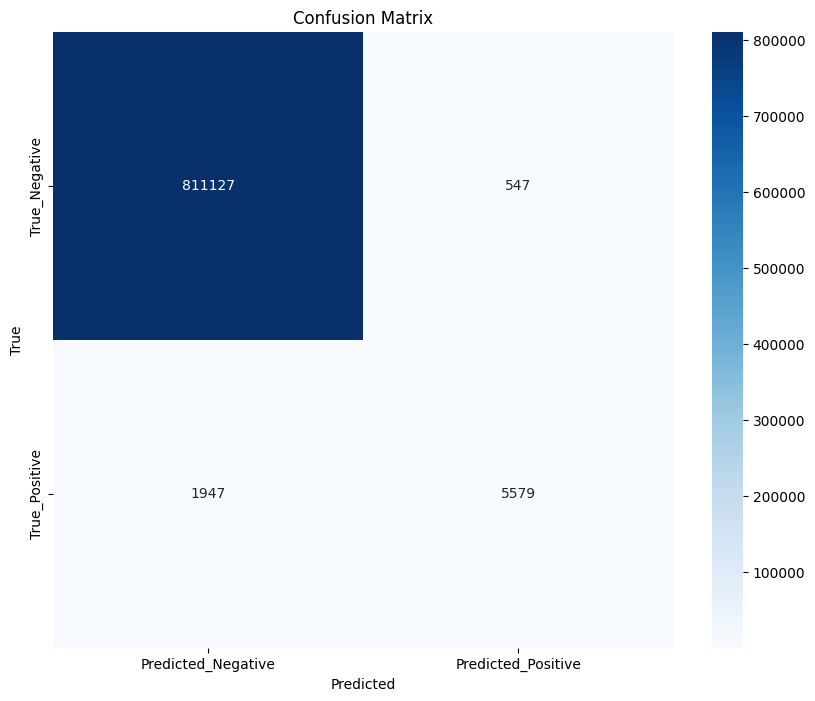

Classification Report
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00    811674
    Positive       0.91      0.74      0.82      7526

    accuracy                           1.00    819200
   macro avg       0.95      0.87      0.91    819200
weighted avg       1.00      1.00      1.00    819200

Precision: 0.9107084557623245
Recall: 0.7412968376295509
F1 Score: 0.8173161441547027
      Metric     Value
0  Precision  0.910708
1     Recall  0.741297
2   F1 Score  0.817316


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

# Load the trained model
from keras.models import load_model
model = load_model('res34_backbone_50epochs.hdf5', compile=False)
# model_path = "/content/drive/MyDrive/Dataset/UNet_Model_save_new_latest.hdf5"
# model = tf.keras.models.load_model(model_path, compile=False)

# Predict all test data
y_pred = []
y_true = []

for img in range(0, X_test.shape[0]):
    temp_img = X_test[img]
    ground_truth = y_test[img]
    # Get the predicted probabilities
    prediction_probs = model.predict(np.expand_dims(temp_img, 0))[0]
    # Get the class with the highest probability
    prediction = np.argmax(prediction_probs, axis=2)  # Get class prediction

    y_pred.append(prediction.flatten())  # Flatten class predictions
    y_true.append(ground_truth[:, :, 0].flatten()) # Flatten ground truth

# Flatten the arrays
y_pred = np.concatenate(y_pred)
y_true = np.concatenate(y_true)

# Ensure y_true and y_pred have the same data type (e.g., int)
y_true = y_true.astype(int)
y_pred = y_pred.astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert the confusion matrix to a DataFrame
cm_df = pd.DataFrame(cm, index=['True_Negative', 'True_Positive'], columns=['Predicted_Negative', 'Predicted_Positive'])

# Save the confusion matrix to a CSV file
cm_df.to_csv('/content/drive/MyDrive/Dataset/confusion_matrix.csv')

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted_Negative', 'Predicted_Positive'], yticklabels=['True_Negative', 'True_Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print('Classification Report')
report = classification_report(y_true, y_pred, target_names=['Negative', 'Positive'])
print(report)

# Save classification report to a text file
with open('/content/drive/MyDrive/Dataset/classification_report.txt', 'w') as f:
    f.write(report)

# Calculate and print Precision, Recall, F1-Score
precision = precision_score(y_true, y_pred, average='binary')
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

# Save metrics to a CSV file
metrics_df = pd.DataFrame({'Metric': ['Precision', 'Recall', 'F1 Score'],
                           'Value': [precision, recall, f1]})
metrics_df.to_csv('/content/drive/MyDrive/Dataset/metrics.csv', index=False)

# Show the metrics DataFrame
print(metrics_df)


In [ ]:
import random
test_img_number = random.randint(0, X_test.shape[0]-1)
test_img = X_test[test_img_number]
ground_truth=y_test[test_img_number]

# Get the predicted probabilities
prediction_probs = model.predict(np.expand_dims(test_img, 0))[0]
# Get the class with the highest probability
prediction = np.argmax(prediction_probs, axis=2)  # Get class prediction

plt.figure(figsize=(16, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img, cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='gray')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(prediction, cmap='gray')

plt.show()

#IoU for a single image
from tensorflow.keras.metrics import MeanIoU
# n_classes was originally set to 2, but it should match the model's output
n_classes = 4  # Assuming 4 classes in your segmentation task
IOU_keras = MeanIoU(num_classes=n_classes)
# Update state with class labels, not probabilities
IOU_keras.update_state(ground_truth[:,:,0], prediction)
print("Mean IoU =", IOU_keras.result().numpy())
print("ground_truth", test_img_number, type(ground_truth[:,:,0]), len(ground_truth[:,:,0]), ground_truth[:,:,0].shape)
print("prediction::", type(prediction), len(prediction), prediction.shape)

import pandas as pd

IoU_Values = []

for img in range(0,X_test.shape[0]):
  temp_img = X_test[img]
  ground_truth = y_test[img]
  # Get the predicted probabilities
  prediction_probs = model.predict(np.expand_dims(temp_img, 0))[0]
  # Get the class with the highest probability
  prediction = np.argmax(prediction_probs, axis=2)  # Get class prediction

  # Plot each image, mask and prediction
  plt.figure(figsize=(16, 8))
  plt.subplot(231)
  plt.title('Testing Image')
  plt.imshow(temp_img, cmap='gray')
  plt.subplot(232)
  plt.title('Testing Label')
  plt.imshow(ground_truth[:,:,0], cmap='gray')
  plt.subplot(233)
  plt.title('Prediction on test image')
  plt.imshow(prediction, cmap='gray')

  plt.show()

  IoU = MeanIoU(num_classes=n_classes)
  IoU.update_state(ground_truth[:,:,0], prediction)
  IoU = IoU.result().numpy()
  IoU_Values.append(IoU)

  print(IoU)

df = pd.DataFrame(IoU_Values, columns = ["IoU"])
df = df[df.IoU != 1.0]

mean_IoU = df.mean().values
print("Mean IoU value for this dataset is : ", mean_IoU)

Output hidden; open in https://colab.research.google.com to view.

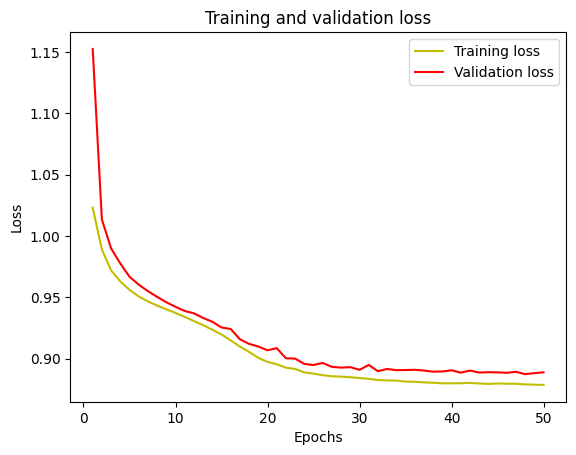

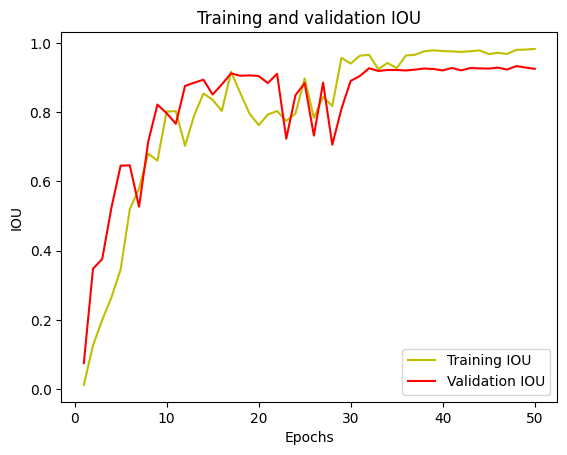

In [ ]:
#plot the training and validation accuracy and loss at each epoch
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history1.history['iou_score']
val_acc = history1.history['val_iou_score']

plt.plot(epochs, acc, 'y', label='Training IOU')
plt.plot(epochs, val_acc, 'r', label='Validation IOU')
plt.title('Training and validation IOU')
plt.xlabel('Epochs')
plt.ylabel('IOU')
plt.legend()
plt.show()